# **Network Attack Detection Model**

### *Sania Ali, Maddie Geittmann, Jackson Horan, Lara Seledotis*
### *Dr. Manar Mohaisen*
### *COMP 379: Machine Learning*
### *28 April 2026*
---------------------------------------



### Install dependencies, import modules, surpress warnings, and set random state

In [125]:
!pip install pandas numpy scikit-learn xgboost seaborn matplotlib pyarrow

In [126]:
import pandas as pd
import numpy as np
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import random


In [127]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

In [128]:
RANDOM_STATE = 379

# **Data Engineering Pipeline - Extract, Transform, Load (ETL)**
-------------------
## Extract
Extracts all network data files including csv, json, and parquet files. The code uses `pd.read_{file type}()` to extracty the data and contain it inside a dataframe. The dataframes are stored in a dictionary `dataframes` that stores a key value pair (name, dataframe) to be able to iterate over each dataframe and apply basic exploratory methods such as `pd.shape` or `pd.head()`. The dataframes are then appended to a list and stacked with `pd.concat` ensuring that only collumns that exist in ALL dataframes are included, this is stored in the datframe `df_all`.

In [129]:
ids_0 = pd.read_csv("content/ids_0.csv")
ids_1 = pd.read_csv("content/ids_1.csv")
ids_2 = pd.read_csv("content/ids_2.csv")
ids_3 = pd.read_json("content/ids_3.json", lines=True)
ids_4_ = pd.read_csv("content/ids_4_.csv")
ids_4 = pd.read_json("content/ids_4.json", lines=True)
ids_5 = pd.read_parquet("content/ids_5.parquet", engine='pyarrow')
ids_6 = pd.read_parquet("content/ids_6.parquet", engine='pyarrow')
ids_7 = pd.read_json("content/ids_7.json", lines=True)
ids_8 = pd.read_parquet("content/ids_8.parquet", engine='pyarrow')
ids_9 = pd.read_json("content/ids_9.json", lines=True)
ids_10 = pd.read_json("content/ids_10.json", lines=True)
ids_11 = pd.read_parquet("content/ids_11.parquet", engine='pyarrow')

In [130]:
dataframes = {
    "ids_0": ids_0, "ids_1": ids_1, "ids_2": ids_2, "ids_3": ids_3,
    "ids_4_": ids_4_, "ids_4": ids_4, "ids_5": ids_5, "ids_6": ids_6,
    "ids_7": ids_7, "ids_8": ids_8, "ids_9": ids_9, "ids_10": ids_10,
    "ids_11": ids_11
}

for name, df in dataframes.items():
     # change method below and run to display certain functions for all dataframes
     display(df.shape)

(1001, 79)

(1001, 79)

(1001, 79)

(1001, 79)

(1001, 79)

...

(10000, 79)

(10293, 79)

(10293, 79)

(5510, 79)

(1025, 79)

In [131]:
dataframes_list = []
for name, df in dataframes.items():
    dataframes_list.append(df)

df_all = pd.concat(dataframes_list, join='inner', ignore_index=True)
df_all.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,53,61205,4,2,136,428,34,34,34.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,53,222,2,2,90,172,45,45,45.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,53,23759,2,2,70,126,35,35,35.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,80,401,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,57406,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


---------
## Transform
The transform section of the code takes the `df_all`, which is the raw network data compiled above, and preforms various oporations to clean the data for pre-processing and will output `clean_df`. These oprations include include stripping columns, replacing spaces with underscores, replacing backslash with _per_, converting all strings to numeric values, replacing infinite values with _NaN_, and dropping negative _Flow_packets_per_s_ data points as we cannot have a negative flow rate. Additionally, the code removes the _heartbleed_ column, and changes labels to binary values (benign or not).

In [132]:
for name, df in dataframes.items():
    print(f"{name}: {df.shape}")
print(f"Previous shape: {df_all.shape}")

ids_0: (1001, 79)
ids_1: (1001, 79)
ids_2: (1001, 79)
ids_3: (1001, 79)
ids_4_: (1001, 79)
ids_4: (1001, 79)
ids_5: (15001, 79)
ids_6: (5001, 79)
ids_7: (10000, 79)
ids_8: (10293, 79)
ids_9: (10293, 79)
ids_10: (5510, 79)
ids_11: (1025, 79)
Previous shape: (63129, 79)


In [133]:
"""
1. strip space before and after collumn names
2. replace white space with '_' and '/' with 'per'
3. convert strings to numeric values
4. replace infinite values with 'NaN'
"""
df_all.columns = [col.strip() for col in df_all.columns]
df_all.columns = [col.replace(' ', '_').replace('/', '_per_') for col in df_all.columns]

df_all['Flow_Packets_per_s'] = pd.to_numeric(df_all['Flow_Packets_per_s'], errors='coerce')
df_all.replace([np.inf, -np.inf], np.nan, inplace=True)
df_all.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63129 entries, 0 to 63128
Data columns (total 79 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Destination_Port             63129 non-null  int64  
 1   Flow_Duration                63129 non-null  int64  
 2   Total_Fwd_Packets            63129 non-null  int64  
 3   Total_Backward_Packets       63129 non-null  int64  
 4   Total_Length_of_Fwd_Packets  63129 non-null  int64  
 5   Total_Length_of_Bwd_Packets  63129 non-null  int64  
 6   Fwd_Packet_Length_Max        63129 non-null  int64  
 7   Fwd_Packet_Length_Min        63129 non-null  int64  
 8   Fwd_Packet_Length_Mean       63129 non-null  float64
 9   Fwd_Packet_Length_Std        63129 non-null  float64
 10  Bwd_Packet_Length_Max        63129 non-null  int64  
 11  Bwd_Packet_Length_Min        63129 non-null  int64  
 12  Bwd_Packet_Length_Mean       63129 non-null  float64
 13  Bwd_Packet_Lengt

In [134]:

"""
1. drops all missing values
2. drops all rows values < 0 in the column since we can't have negative flow rate
3. to handle label column we will remove the heartbleed label.
4. we will convert the labels to binary values to the data can be processed
"""
clean_df = df_all.dropna(subset=['Flow_Packets_per_s'])
clean_df = clean_df[clean_df['Flow_Packets_per_s'] >= 0]
clean_df = clean_df[clean_df['Label'] != 'Heartbleed']
clean_df['Label'] = clean_df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

In [135]:
""" cleaned data shape has less rows than the original data which shows our cleaning
was useful to remove missing data"""
for name, df in dataframes.items():
    print(f"{name}: {df.shape}")
print(f"Cleaned Data shape: {clean_df.shape}")

clean_df.describe()

ids_0: (1001, 79)
ids_1: (1001, 79)
ids_2: (1001, 79)
ids_3: (1001, 79)
ids_4_: (1001, 79)
ids_4: (1001, 79)
ids_5: (15001, 79)
ids_6: (5001, 79)
ids_7: (10000, 79)
ids_8: (10293, 79)
ids_9: (10293, 79)
ids_10: (5510, 79)
ids_11: (1025, 79)
Cleaned Data shape: (62995, 79)


,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label
count,62995.000000,6.299500e+04,62995.000000,62995.000000,62995.000000,6.299500e+04,62995.000000,62995.000000,62995.000000,62995.000000,...,62995.000000,6.299500e+04,6.299500e+04,6.299500e+04,6.299500e+04,6.299500e+04,6.299500e+04,6.299500e+04,6.299500e+04,62995.000000
mean,993.146043,4.190967e+07,6.411207,5.043543,401.773776,8.852840e+03,261.249623,12.310501,61.744852,102.021738,...,29.574982,4.170033e+05,3.255811e+04,4.453519e+05,3.919055e+05,3.676185e+07,1.032932e+06,3.776323e+07,3.592942e+07,0.904738
std,6699.995833,4.278236e+07,106.928059,144.977586,2315.800140,3.239101e+05,317.656495,124.974455,143.825672,120.883990,...,5.554489,1.563957e+06,4.116409e+05,1.657047e+06,1.533256e+06,4.274944e+07,5.573494e+06,4.284962e+07,4.303808e+07,0.293578
min,0.000000,1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,80.000000,1.487720e+05,2.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
50%,80.000000,1.196216e+07,6.000000,5.000000,336.000000,5.990000e+03,325.000000,0.000000,46.875000,123.236706,...,32.000000,4.700000e+02,0.000000e+00,4.700000e+02,3.860000e+02,6.896736e+06,0.000000e+00,6.896736e+06,6.861200e+06,1.000000
75%,80.000000,8.578604e+07,8.000000,6.000000,397.000000,1.159500e+04,373.000000,0.000000,68.333333,156.106374,...,32.000000,1.997000e+03,0.000000e+00,1.997000e+03,1.991000e+03,8.510000e+07,0.000000e+00,8.530000e+07,8.510000e+07,1.000000
max,64249.000000,1.199997e+08,18649.000000,25335.000000,312775.000000,5.610000e+07,11595.000000,1983.000000,2319.000000,5185.441640,...,56.000000,1.370000e+07,1.280000e+07,3.030000e+07,1.370000e+07,1.200000e+08,6.070000e+07,1.200000e+08,1.200000e+08,1.000000


-------
## Load
#### This section loads the cleaned data, `clean_df`, into a csv, json, and parquet file for the exploratory data analysis (EDA). csv is easy to manually inspect, JSON and parquet allow for more development options in the future.

In [136]:
clean_df.to_csv("cleaned_raw_data.csv", index=False)
clean_df.to_json("cleaned_raw_data.json", orient='records', lines=True)
clean_df.to_parquet("cleaned_raw_data.parquet", compression='gzip')

------
## Log
#### This section of the code logs the final shape of the dataset aftr ETL pipeline.

In [137]:
log_file = 'etl_log_file.txt'
db_name = 'network_attack_data.db'
table_name = 'cleaned_data'
def log(logfile: str, message: str) -> None:
    """ function to log the message and time of occurrence """
    datatime_format = '%Y-%m-%d-%H:%M:%S.%f, '
    datetimestamp = datetime.now().strftime(datatime_format)

    ## log events are separated by the new character
    with open(logfile, 'a') as file:
        file.write(datetimestamp + message + '\n')

#log data text file
log(log_file, f"Final shape: {clean_df.shape}")

-----------
# **Exploratory Data Analysis**

#### The following sections of code are exploring patterns within and between features. Each distinct technique is documented in place.

#### First, split the dataframe into the 78 features and the one label to explore them both together and separately. We'll use pandas to perform these analytical oporations.

In [138]:
clean_df.shape # 62995 samples, 78 features, 1 label
y = clean_df[['Label']] # target
X = clean_df.loc[:, clean_df.columns != 'Label'] # features

#### Examine which features have a large number of unique values. This will help identifying the columns that may contain outliers, have very high/low variance, and have more or less informative value in predicting the Label.

In [139]:
# number of unique values in each column
thresh = 10000
high_unique = {}
for c,v in X.items():
    num_unique = v.nunique()
    if num_unique > thresh:
        high_unique[c] = num_unique

print(f'Columns with a lot of variability: {high_unique.keys()}\nCount: {len(high_unique)}')
# likely have outliers

Columns with a lot of variability: dict_keys(['Flow_Duration', 'Flow_Bytes_per_s', 'Flow_Packets_per_s', 'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std', 'Bwd_IAT_Max', 'Fwd_Packets_per_s', 'Bwd_Packets_per_s', 'Packet_Length_Std', 'Packet_Length_Variance'])
Count: 18


#### Now identify which features have variance below a certain threshold. These features have very low variability and likely do not have predictive value. During feature selection, these features will likely be removed.

In [140]:
# find features with very low variance
var_threshold = 1
X.describe()
low_var = {}
for c,v in X.items():
    var = v.var()
    if var < var_threshold:
        low_var[c] = var

# These columns should be removed later
# Primarily columns that contain Flag and Bulk
print(f'Columns with variance below {var_threshold}: {low_var.keys()}\nCount: {len(low_var)}')

Columns with variance below 1: dict_keys(['Fwd_PSH_Flags', 'Bwd_PSH_Flags', 'Fwd_URG_Flags', 'Bwd_URG_Flags', 'FIN_Flag_Count', 'SYN_Flag_Count', 'RST_Flag_Count', 'PSH_Flag_Count', 'ACK_Flag_Count', 'URG_Flag_Count', 'CWE_Flag_Count', 'ECE_Flag_Count', 'Down_per_Up_Ratio', 'Fwd_Avg_Bytes_per_Bulk', 'Fwd_Avg_Packets_per_Bulk', 'Fwd_Avg_Bulk_Rate', 'Bwd_Avg_Bytes_per_Bulk', 'Bwd_Avg_Packets_per_Bulk', 'Bwd_Avg_Bulk_Rate'])
Count: 19


#### Once outliers are removed, the above code may be ran again because variance & number of unique features will likely drop. Most of the data is skewed **RIGHT**, so outliers are **HIGH** values. Next, I am looking at the distribution of benign and attack labels. The following code identifies 6,001 `0` labels, and 56,994 `1` labels.

In [141]:
label = y.to_numpy().squeeze()
np.unique(label, return_counts=True)

(array([0, 1]), array([ 6001, 56994]))

#### Confirmation that the dataset no longer contains missing data.

In [142]:
for c,v in X.items():
    if v.isnull().sum() > 0:
        print(v)


-------------------------
## Data Visualization: Bivariate Analysis

In [143]:
# correlation matrix (includes Label)
corr_matrix = clean_df.corr()

# extracting information from this correlation matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# gather features that have a strong correlation
# some of these features should be removed as they do not provide additional information
threshold = 0.9
strong_corr = upper_tri.stack().reset_index()
strong_corr.columns = ['Feature1', 'Feature2', 'Correlation Coefficient']

# dataframe containing features with a correlation coefficient greater than a threshold
strong_corr = strong_corr[strong_corr['Correlation Coefficient'].abs() > threshold].reset_index(drop=True)
print(f"Features with correlation above {threshold}: {strong_corr[['Feature1', 'Feature2']]}")


Features with correlation above 0.9:                         Feature1                     Feature2
0                  Flow_Duration                 Flow_IAT_Max
1                  Flow_Duration                Fwd_IAT_Total
2                  Flow_Duration                  Fwd_IAT_Max
3                  Flow_Duration                    Idle_Mean
4                  Flow_Duration                     Idle_Max
5                  Flow_Duration                     Idle_Min
6              Total_Fwd_Packets       Total_Backward_Packets
7              Total_Fwd_Packets  Total_Length_of_Bwd_Packets
8              Total_Fwd_Packets            Fwd_Header_Length
9              Total_Fwd_Packets            Bwd_Header_Length
10             Total_Fwd_Packets          Fwd_Header_Length.1
11             Total_Fwd_Packets          Subflow_Fwd_Packets
12             Total_Fwd_Packets          Subflow_Bwd_Packets
13             Total_Fwd_Packets            Subflow_Bwd_Bytes
14             Total_Fwd_Packets 

<Axes: xlabel='Label', ylabel='Destination_Port'>

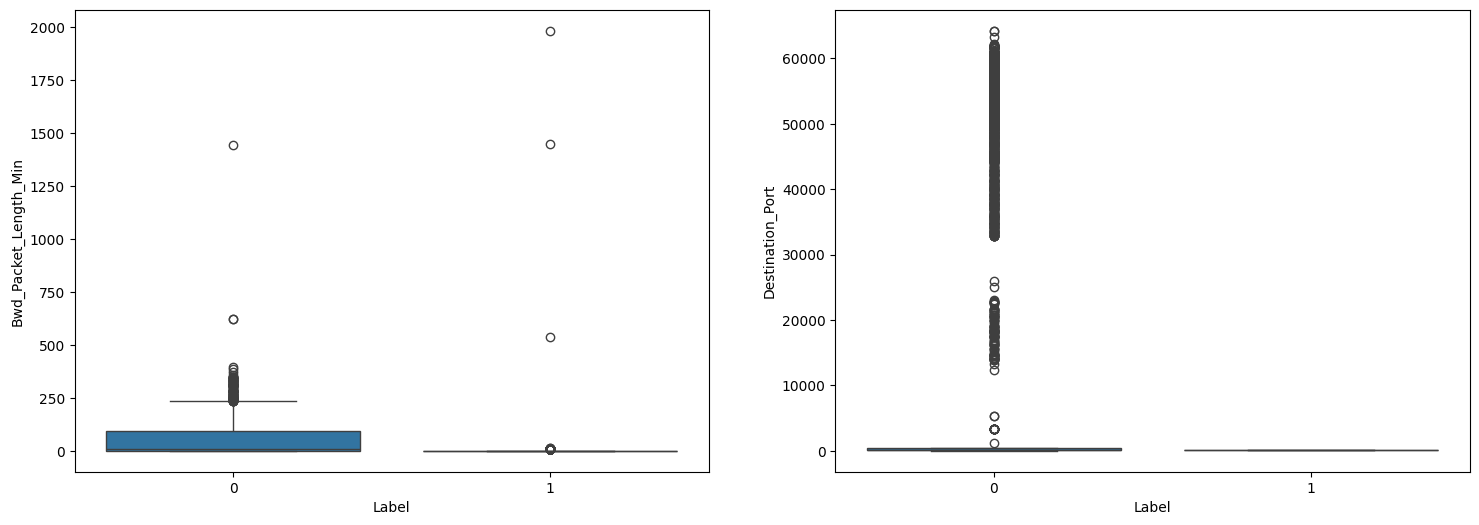

In [144]:
# correlations with Label
threshold = 0.3
corr_y = clean_df.corr()['Label'].drop('Label')
corr = {c:v for c,v in corr_y.items() if v > threshold}

# visualize these
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(y=clean_df['Bwd_Packet_Length_Min'], x=clean_df['Label'], ax=axes[0])
sns.boxplot(y=clean_df['Destination_Port'], x=clean_df['Label'], ax=axes[1])

# Bwd Packet Length Min & Label: r=-0.5329
# Destination Port & Label: r=-0.420

#### The following cell examines correlations between data within the same feature category. This can inform feature selection to determine which subfeatures are the most informative. Function in `pattern_features` can be changed (eg: `.startswith()`, `.endswith()`) as needed.

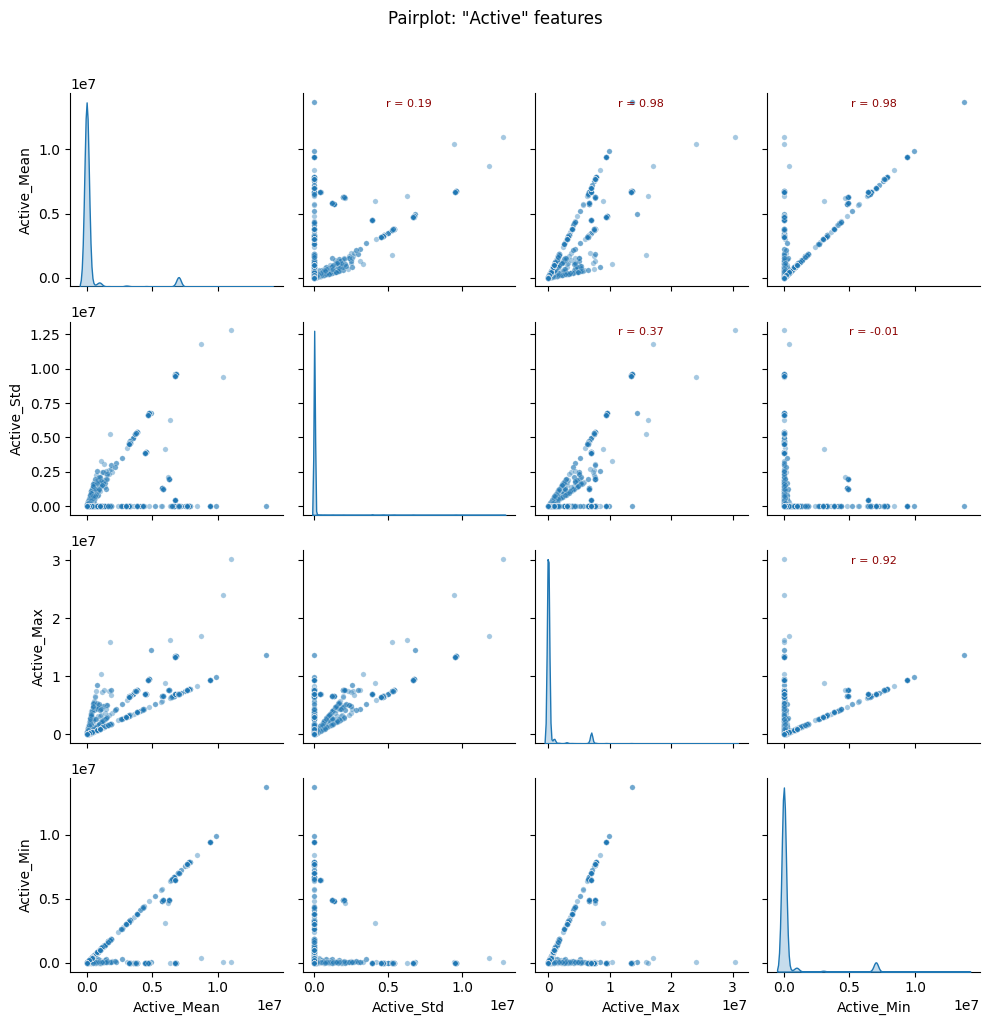

In [145]:
contains = 'Active'

# Select columns matching the 'contains'
pattern_features = [col for col in clean_df.columns if col.startswith(contains)]
subset_features = list(dict.fromkeys(pattern_features))

# Pairplot
subset_df = clean_df[subset_features].dropna()

pair_grid = sns.pairplot(
    subset_df,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15},)  # semi-transparent points for dense data

# Annotate each off-diagonal cell with its correlation coefficient
for i, j in zip(*np.triu_indices_from(pair_grid.axes, k=1)):
    r = subset_df[subset_features[j]].corr(subset_df[subset_features[i]])
    pair_grid.axes[i, j].annotate(f'r = {r:.2f}', xy=(0.5, 0.97),
                                   xycoords='axes fraction', ha='center', va='top',
                                   fontsize=8, color='darkred')

pair_grid.figure.suptitle(f'Pairplot: "{contains}" features', y=1.02)
plt.tight_layout()
plt.show()

<Axes: >

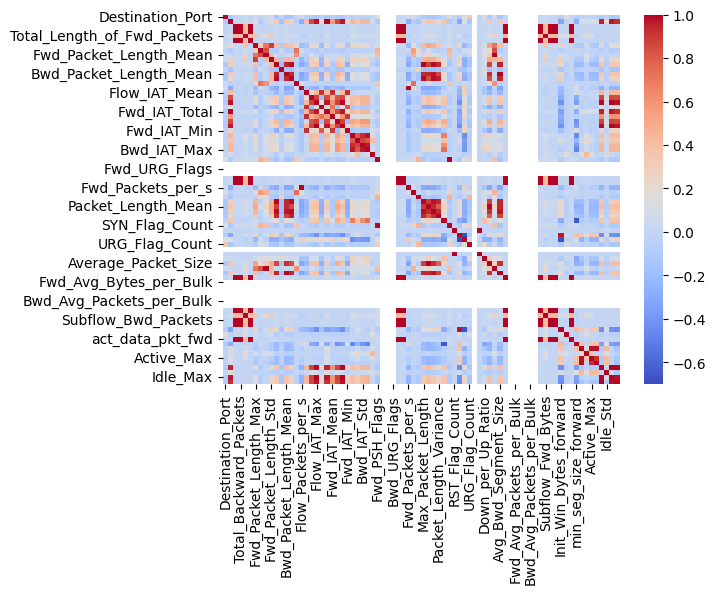

In [146]:
full_corr = clean_df.iloc[:,:-1].corr()
sns.heatmap(full_corr, cmap='coolwarm')

#### The features below appear to have some relevance with eachother.

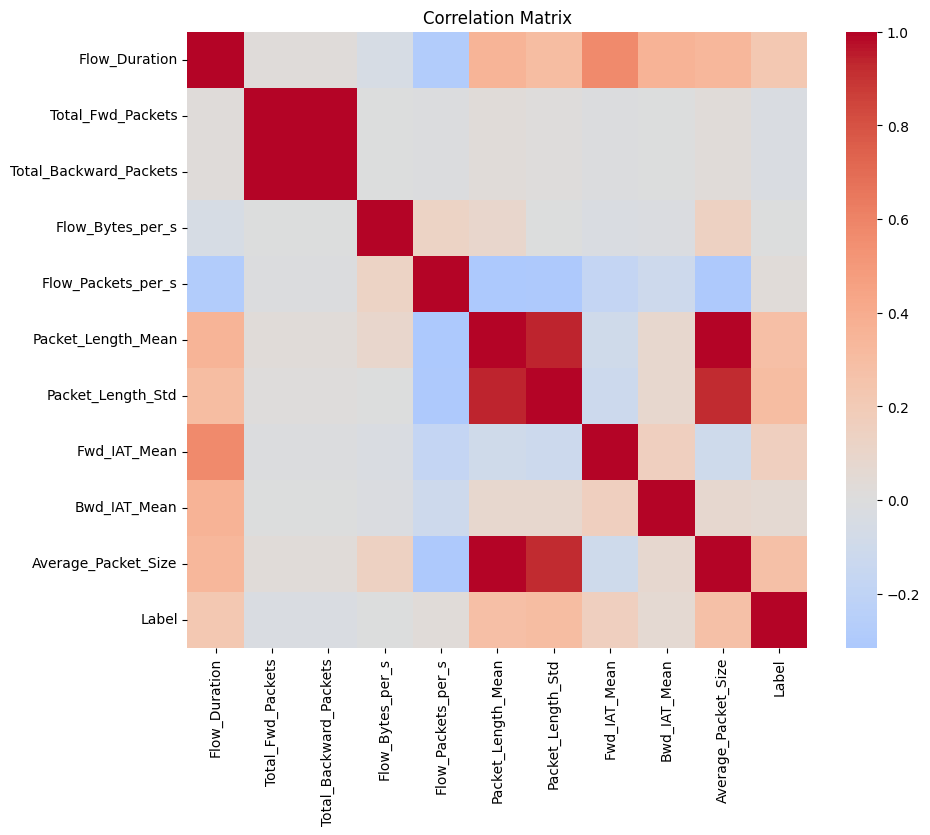

In [147]:
pairplot_cols = [
    'Flow_Duration',
    'Total_Fwd_Packets',
    'Total_Backward_Packets',
    'Flow_Bytes_per_s',
    'Flow_Packets_per_s',
    'Packet_Length_Mean',
    'Packet_Length_Std',
    'Fwd_IAT_Mean',
    'Bwd_IAT_Mean',
    'Average_Packet_Size',
    'Label']

# visualized correlation matrix of the subset columns chosen
data_subset = clean_df[pairplot_cols].copy()

# correlation matrix
corr_matrix = data_subset.corr(numeric_only=True)

# heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

#### Many features seem to have high outliers. Below, we identify outliers in the features chosen above, but no outliers are removed from the dataset.

Outlier counts: {'Flow_Duration': 0, 'Total_Fwd_Packets': 591, 'Total_Backward_Packets': 451, 'Flow_Bytes_per_s': 6438, 'Flow_Packets_per_s': 13881, 'Packet_Length_Mean': 0, 'Packet_Length_Std': 0, 'Fwd_IAT_Mean': 3004, 'Bwd_IAT_Mean': 7850, 'Average_Packet_Size': 0}


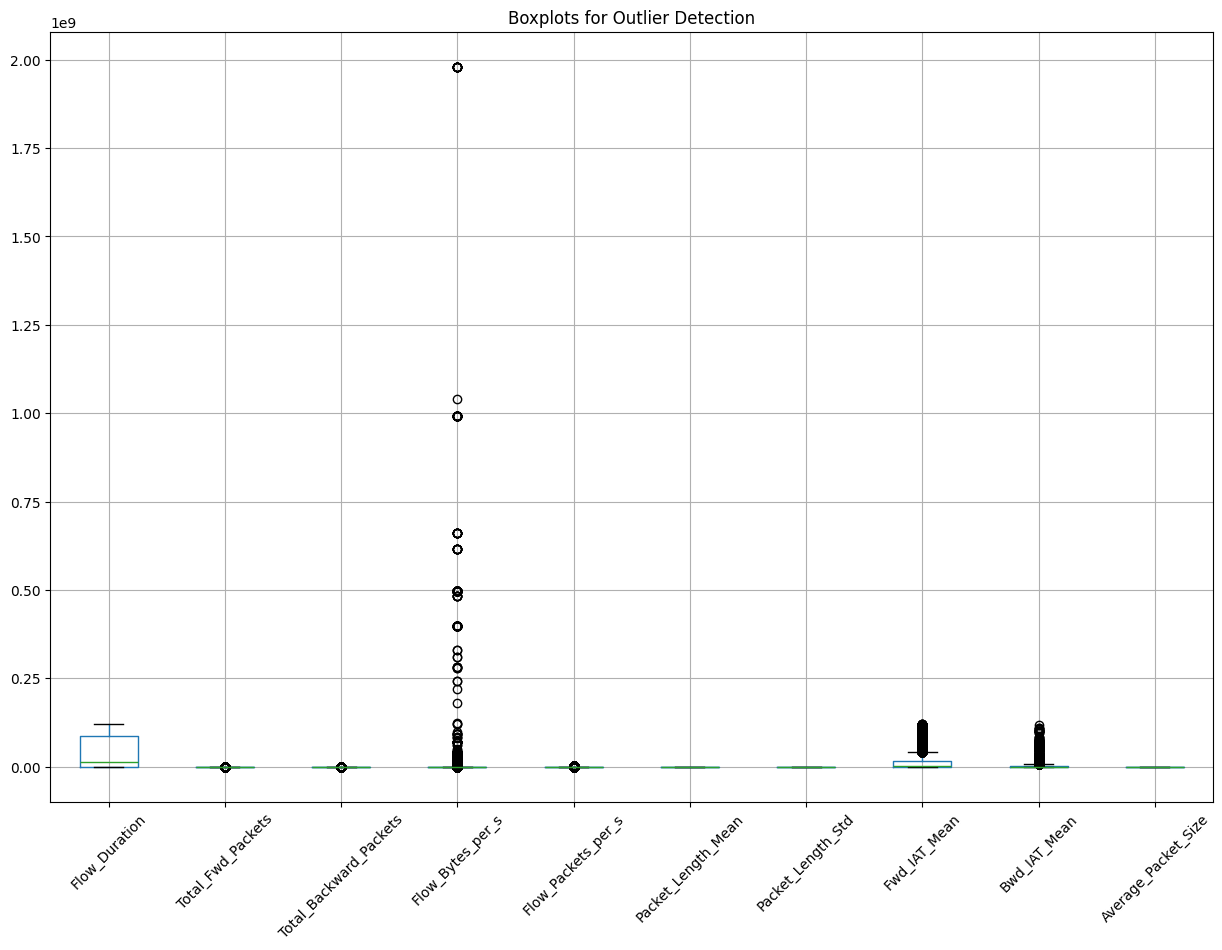

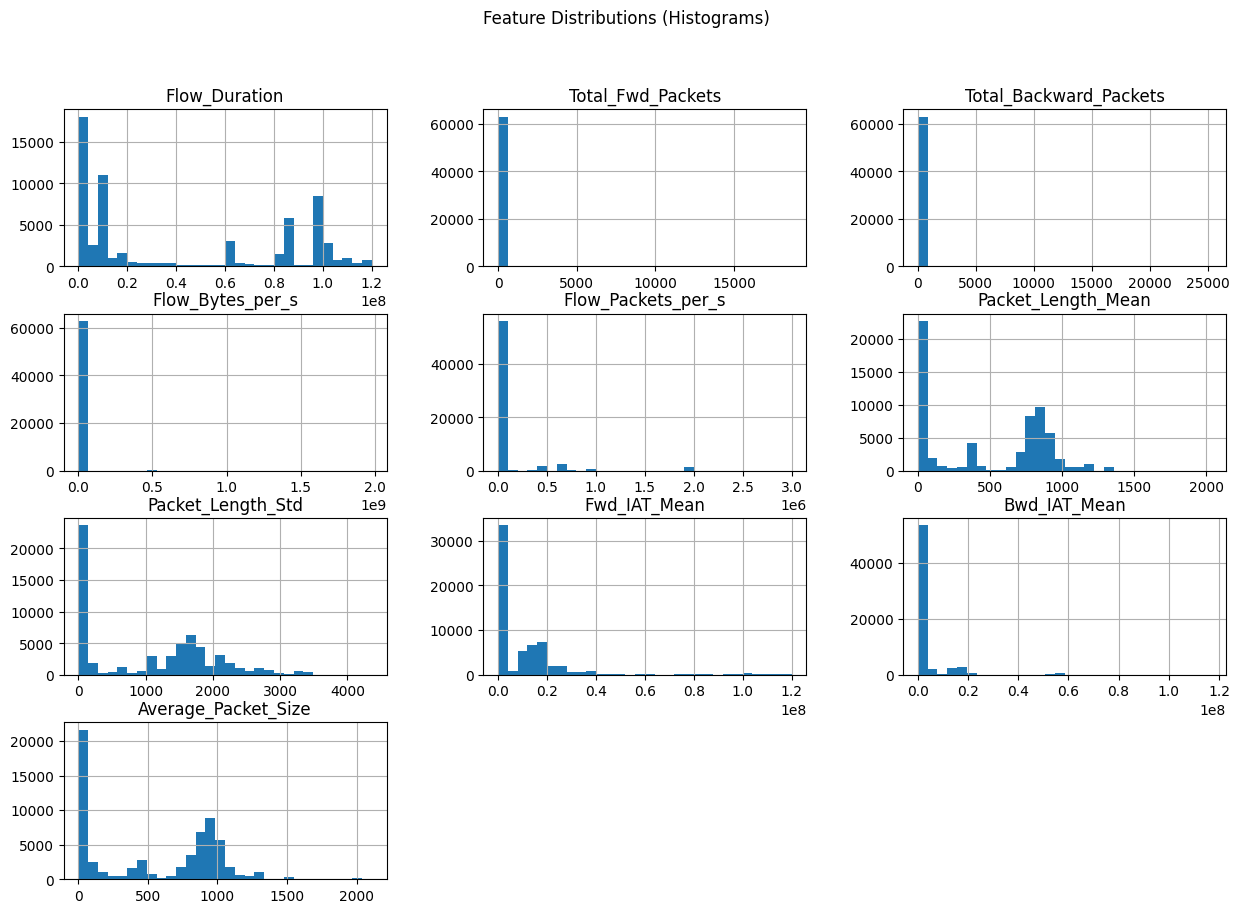

In [148]:
"""Identification of outliers in selected features."""

numeric_cols = [col for col in pairplot_cols if col != 'Label']
outlier_counts = {}

for col in numeric_cols:               # looping through each numeric column to detect outliers
    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR # computing the lower bound
    upper_bound = Q3 + 1.5 * IQR # computing the upper bound

    outliers = clean_df[(clean_df[col] < lower_bound) | (clean_df[col] > upper_bound)] # filtering rows where values are outside the bounds (considered outliers)
    outlier_counts[col] = len(outliers)

outlier_counts

print(f"Outlier counts: {outlier_counts}")
plt.figure(figsize=(15, 10))                             # created both boxplots and histograms to visualize the outliers
clean_df[numeric_cols].boxplot(rot=45)
plt.title("Boxplots for Outlier Detection")
plt.show()

clean_df[numeric_cols].hist(figsize=(15, 10), bins=30)
plt.suptitle("Feature Distributions (Histograms)")
plt.show()

-------------------------
## Data Visualization: Univariate Analysis

#### Mostly doing univariate analyses on features that have a high variability (as defined above). Many features are providing the same information. We Tried to group potentially related features together.

<Axes: xlabel='Destination_Port', ylabel='Count'>

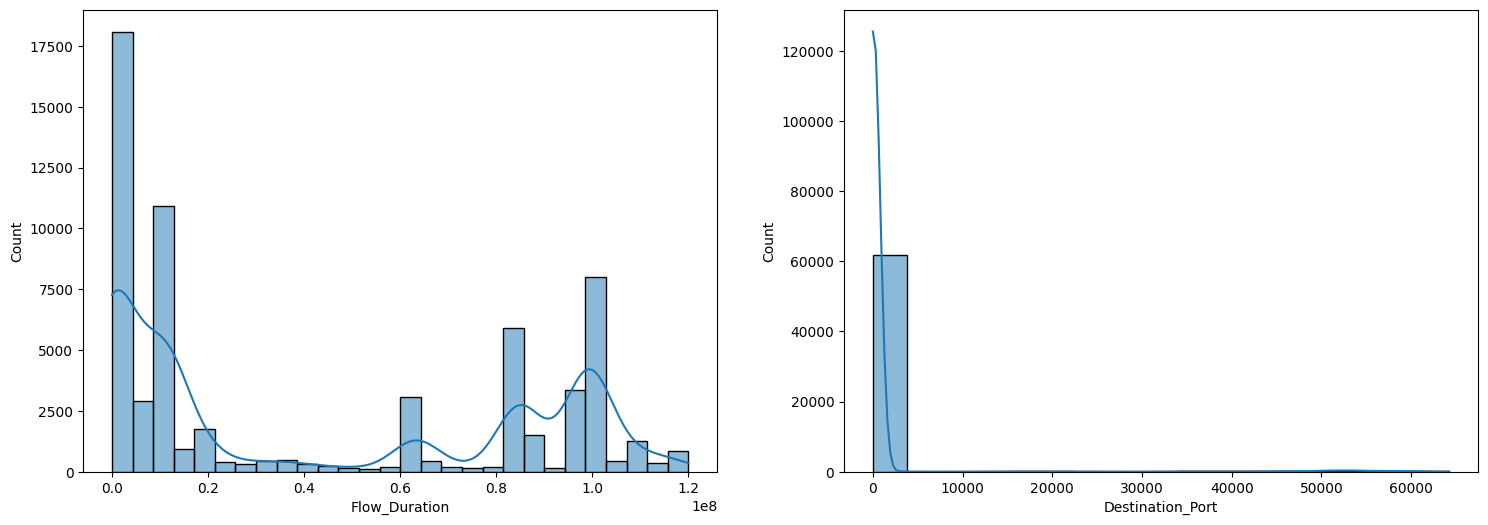

In [149]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(X['Flow_Duration'], kde=True, ax=axes[0])
sns.histplot(X['Destination_Port'], kde=True, ax=axes[1])

<Axes: xlabel='Total_Backward_Packets', ylabel='Count'>

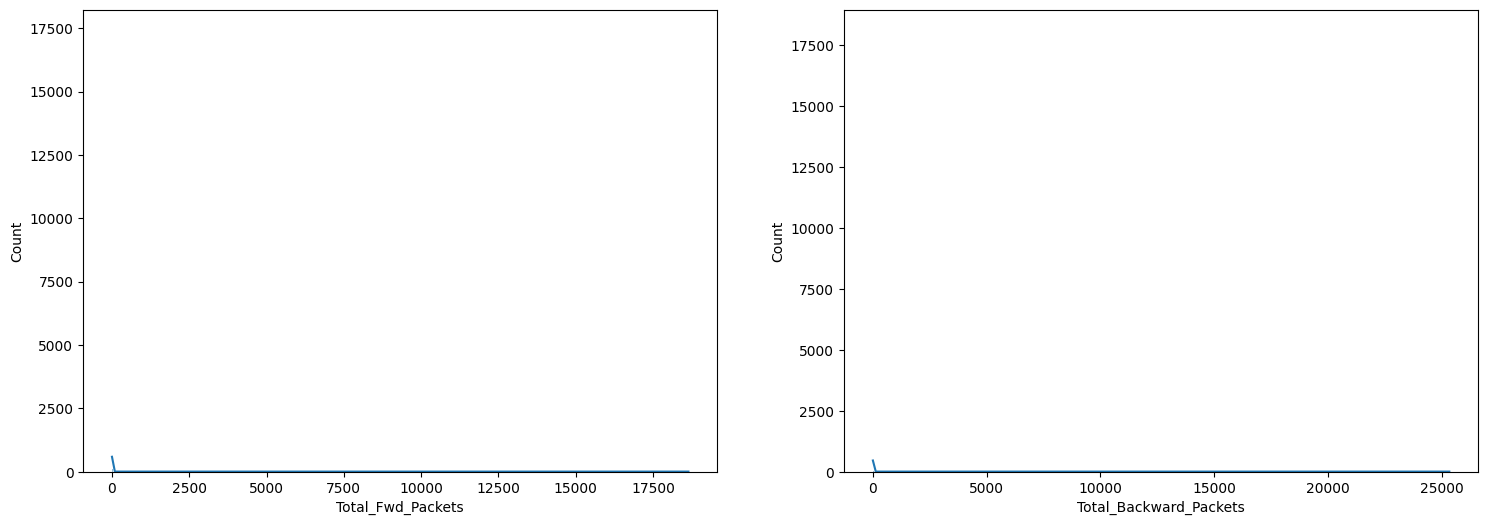

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(X['Total_Fwd_Packets'], kde=True, ax=axes[0])
sns.histplot(X['Total_Backward_Packets'], kde=True, ax=axes[1])

<Axes: xlabel='Packet_Length_Std', ylabel='Count'>

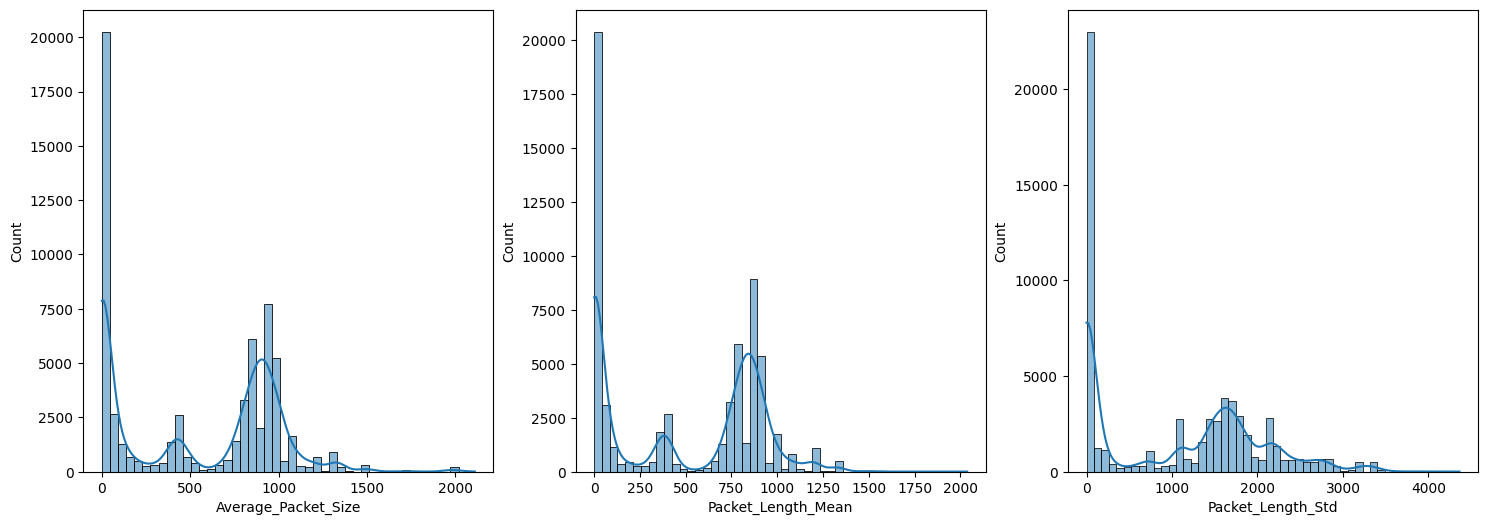

In [151]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.histplot(X['Average_Packet_Size'], kde=True, ax=axes[0])
sns.histplot(X['Packet_Length_Mean'], kde=True, ax=axes[1])
sns.histplot(X['Packet_Length_Std'], kde=True, ax=axes[2])

<Axes: xlabel='Fwd_IAT_Mean', ylabel='Bwd_IAT_Mean'>

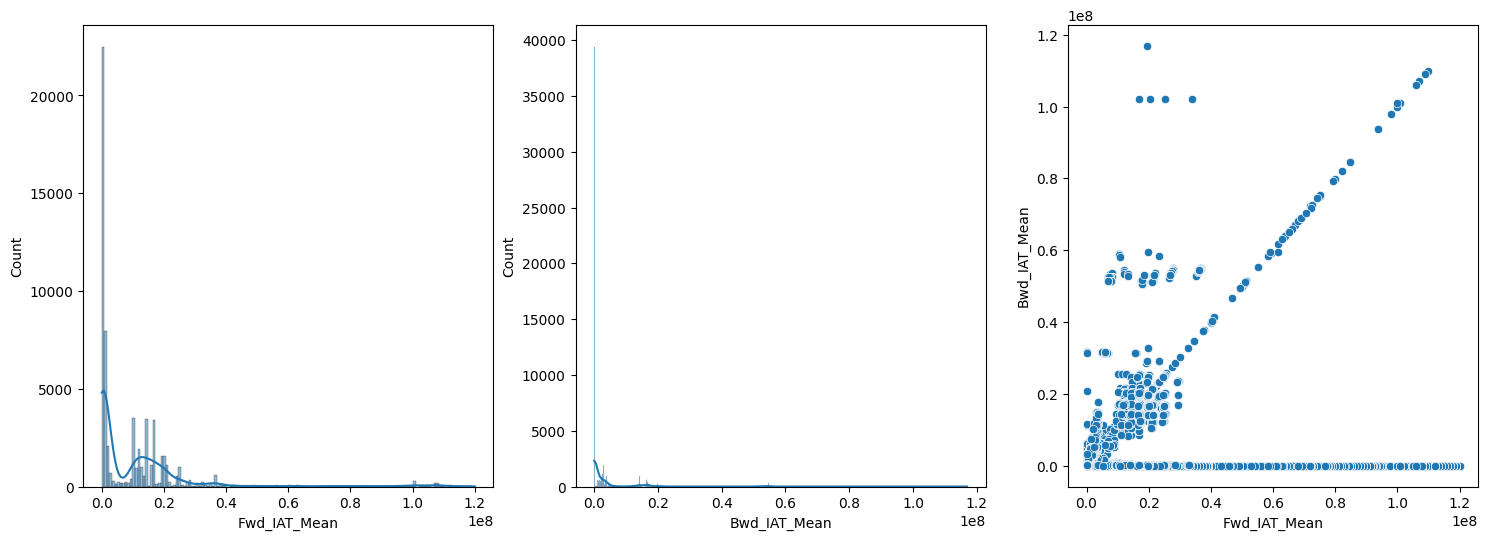

In [152]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.histplot(X['Fwd_IAT_Mean'], kde=True, ax=axes[0])
sns.histplot(X['Bwd_IAT_Mean'], kde=True, ax=axes[1])
sns.scatterplot(x=X['Fwd_IAT_Mean'], y=X['Bwd_IAT_Mean'], ax=axes[2])

-------------------------
## Data Visualization: Multivariate Analysis
#### Performing cluster analysis on selected features of the dataset.

In [153]:
# Use subset titled pairplot_cols
subset = clean_df[pairplot_cols].copy()
subset = subset.loc[:, subset.columns != 'Flow_Bytes_per_s']
subset_X = subset.loc[:, subset.columns != 'Label']
subset_y = subset[['Label']].copy()

# standardized features before performing cluster analysis
scaler = StandardScaler()
scaled_features = scaler.fit_transform(subset_X)

In [154]:
# define kmeans parameters
kmeans = KMeans(init="random",
                n_clusters=2,  # two class labels, 0 and 1
                n_init=10,
                max_iter=200,
                random_state=379)
kmeans.fit(scaled_features)

# calculate silhouette scores, a means of quantifying performance of cluster analyses
kmeans_silhouette = silhouette_score(scaled_features, kmeans.labels_)

print(f'K-means silhouette score: {kmeans_silhouette}')

K-means silhouette score: 0.44884880502236363


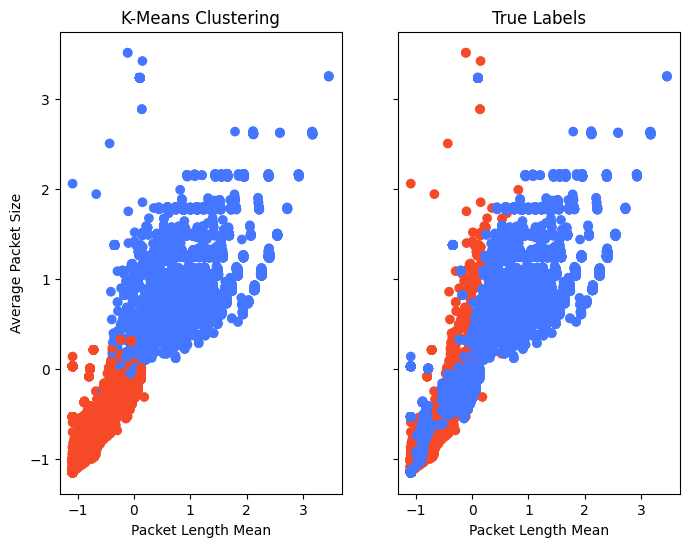

In [155]:
# Plot data and cluster analysis for comparison
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(8,6),
                              sharex=True, sharey=True)
colors = {0: "#F54927", 1:"#4476FF"}
# set x and y labels
ax1.set_xlabel('Packet Length Mean')
ax2.set_xlabel('Packet Length Mean')
ax1.set_ylabel('Average Packet Size')
# titles
ax1.set_title('K-Means Clustering')
ax2.set_title('True Labels')
# kmeans plot
km_colors = [colors[label] for label in kmeans.labels_]
real_colors = [colors[label] for label in subset_y['Label']]
ax1.scatter(scaled_features[:,5], scaled_features[:,8], c=km_colors)
ax2.scatter(scaled_features[:,5], scaled_features[:,8], c=real_colors)
plt.show()

# **Machine Learning Pipeline**
-------------------
## Data Pre-Processing
#### It's important to consider data leakage. Is data time correlated? If so, split should be by time, and not randomly. Data has not been scaled and missing data has been removed. Have duplicates been handled?

In [156]:
# first, drop duplicate entries from clean_df
clean_df2 = clean_df.drop_duplicates()
print(f'Number of duplicate samples dropped: {len(clean_df)-len(clean_df2)}.')

Number of duplicate samples dropped: 13647.


#### Next, it is best practices to randomize the order of the samples in the dataset before splitting. This will avoid detection of any patterns simply from the order in which samples are listed.

In [157]:
new_clean_df = clean_df2.sample(frac=1, random_state=379).reset_index(drop=True)

-------------------
## Processed Data Loading
Export `new_clean_df` to CSV.

In [158]:
new_clean_df.to_csv("processed_data.csv", index=False)

-------------------
## Feature Engineering
#### Split randomized datframe into feature set and lable set.

In [159]:
# split this shuffled dataframe into features & target
new_clean_df.shape # 49487 samples, 78 features, 1 label
y2 = new_clean_df[['Label']] # target
X2 = new_clean_df.loc[:, clean_df.columns != 'Label'] # features

#### Finally, split dataframe into training, validation and testing datasets. The validation dataset will assist with feature selection. For data sets with ~50k samples, a 70-15-15 split is seen as the best approach. Stratified because Label is imbalanced .

In [160]:
# First split: separate test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X2, y2,
    test_size=0.15,
    random_state=379,
    stratify=y2
)

# Second split: separate validation from training
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # very close to a 70-15-15 split
    random_state=379,
    stratify=y_temp
)

print(f'Confirm datasets are correct proportion of intitial data:\n{X_train.size/X2.size}, {X_val.size/X2.size}, {X_val.size/X2.size}\n{y_train.size/y2.size}, {y_val.size/y2.size}, {y_val.size/y2.size}')

Confirm datasets are correct proportion of intitial data:
0.7003728621220718, 0.14961092648131635, 0.14961092648131635
0.7003728621220718, 0.14961092648131635, 0.14961092648131635


In [161]:
feature_means = X_train.mean()
feature_stds = X_train.std()

stats_df = pd.DataFrame({ # combines the results into a df for easier viewing
    'Mean': feature_means,
    'Std': feature_stds
})
pd.set_option('display.max_rows', None)

print(stats_df) # many features with 0 variance

                                     Mean           Std
Destination_Port             1.038517e+03  6.842454e+03
Flow_Duration                4.992920e+07  4.275085e+07
Total_Fwd_Packets            7.113535e+00  1.037098e+02
Total_Backward_Packets       5.845032e+00  1.403522e+02
Total_Length_of_Fwd_Packets  4.551623e+02  2.342238e+03
Total_Length_of_Bwd_Packets  1.026936e+04  3.163264e+05
Fwd_Packet_Length_Max        2.926916e+02  3.079142e+02
Fwd_Packet_Length_Min        6.315636e+00  5.950453e+01
Fwd_Packet_Length_Mean       6.348776e+01  9.894212e+01
Fwd_Packet_Length_Std        1.175472e+02  1.227706e+02
Bwd_Packet_Length_Max        3.933709e+03  3.236656e+03
Bwd_Packet_Length_Min        5.359644e+00  3.048329e+01
Bwd_Packet_Length_Mean       1.231213e+03  9.406677e+02
Bwd_Packet_Length_Std        1.687842e+03  1.433435e+03
Flow_Bytes_per_s             3.810335e+05  1.255417e+07
Flow_Packets_per_s           8.601304e+03  9.334433e+04
Flow_IAT_Mean                8.168159e+06  1.512

#### Remove zero variance features.

In [162]:
zero_var_features = feature_stds[feature_stds == 0].index # finds features with zero var

print("Zero variance features:")
print(zero_var_features)

X_train = X_train.drop(columns=zero_var_features) # drops them
X_val = X_val.drop(columns=zero_var_features)
X_test = X_test.drop(columns=zero_var_features)

Zero variance features:
Index(['Bwd_PSH_Flags', 'Fwd_URG_Flags', 'Bwd_URG_Flags', 'CWE_Flag_Count',
       'Fwd_Avg_Bytes_per_Bulk', 'Fwd_Avg_Packets_per_Bulk',
       'Fwd_Avg_Bulk_Rate', 'Bwd_Avg_Bytes_per_Bulk',
       'Bwd_Avg_Packets_per_Bulk', 'Bwd_Avg_Bulk_Rate'],
      dtype='object')


#### Scale the features.

In [163]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)            # scale the features
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)

#### Examine the mean and standard deviation of all features.

In [164]:
scaled_stats = pd.DataFrame({
    'Mean': X_train_scaled.mean(),
    'Std': X_train_scaled.std()
})

with pd.option_context('display.max_rows', None):
    print(scaled_stats)

                                     Mean       Std
Destination_Port            -3.392152e-17  1.000014
Flow_Duration               -5.509677e-17  1.000014
Total_Fwd_Packets            1.439095e-18  1.000014
Total_Backward_Packets       6.475926e-18  1.000014
Total_Length_of_Fwd_Packets -1.747472e-18  1.000014
Total_Length_of_Bwd_Packets  6.167549e-19  1.000014
Fwd_Packet_Length_Max        9.477467e-17  1.000014
Fwd_Packet_Length_Min       -1.644680e-18  1.000014
Fwd_Packet_Length_Mean      -6.784304e-18  1.000014
Fwd_Packet_Length_Std       -2.456740e-17  1.000014
Bwd_Packet_Length_Max        4.666779e-17  1.000014
Bwd_Packet_Length_Min       -4.368680e-17  1.000014
Bwd_Packet_Length_Mean      -7.113240e-17  1.000014
Bwd_Packet_Length_Std       -1.182114e-16  1.000014
Flow_Bytes_per_s            -5.653586e-18  1.000014
Flow_Packets_per_s           5.961964e-18  1.000014
Flow_IAT_Mean                5.468560e-17  1.000014
Flow_IAT_Std                 6.825421e-17  1.000014
Flow_IAT_Max

#### Perform Lasso regularization.

In [165]:
lasso = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=RANDOM_STATE)
lasso.fit(X_train_scaled, y_train) # fit the lasso model

coef = lasso.coef_[0] # extract model coefficients (one per feature)

lasso_features = X_train_scaled.columns[coef != 0] # find features with non-zero coefficients

print("Selected features with Lasso:", len(lasso_features))
print(lasso_features)

Selected features with Lasso: 41
Index(['Destination_Port', 'Total_Length_of_Fwd_Packets',
       'Fwd_Packet_Length_Max', 'Fwd_Packet_Length_Min',
       'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max',
       'Bwd_Packet_Length_Min', 'Bwd_Packet_Length_Mean',
       'Bwd_Packet_Length_Std', 'Flow_Bytes_per_s', 'Flow_IAT_Mean',
       'Flow_IAT_Std', 'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Min',
       'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Min', 'Fwd_PSH_Flags',
       'Fwd_Header_Length', 'Bwd_Header_Length', 'Fwd_Packets_per_s',
       'Bwd_Packets_per_s', 'Min_Packet_Length', 'Packet_Length_Std',
       'FIN_Flag_Count', 'SYN_Flag_Count', 'PSH_Flag_Count', 'ACK_Flag_Count',
       'URG_Flag_Count', 'Down_per_Up_Ratio', 'Average_Packet_Size',
       'Avg_Bwd_Segment_Size', 'Fwd_Header_Length.1', 'Subflow_Fwd_Bytes',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward',
       'min_seg_size_forward', 'Active_Mean', 'Active_Std', 'Idle_Std'],
      dtype='object')


#### Perform Random Forest feature selection.

In [166]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train_scaled, y_train) # fit the random forest model

importances = rf.feature_importances_  # get feature importance scores

rf_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': importances                       # put them in a df and rank them from most important to least important
}).sort_values(by='Importance', ascending=False)


rf_features = rf_df[rf_df['Importance'] > 0.01]['Feature'] # find features with importance greater than 0.01

print("Selected features with Random Forest:", len(rf_features))
print(rf_features)

Selected features with Random Forest: 29
0                Destination_Port
35              Min_Packet_Length
20                  Fwd_IAT_Total
21                   Fwd_IAT_Mean
23                    Fwd_IAT_Max
11          Bwd_Packet_Length_Min
56         Init_Win_bytes_forward
57        Init_Win_bytes_backward
54            Subflow_Bwd_Packets
16                  Flow_IAT_Mean
3          Total_Backward_Packets
15             Flow_Packets_per_s
34              Bwd_Packets_per_s
7           Fwd_Packet_Length_Min
5     Total_Length_of_Bwd_Packets
32              Bwd_Header_Length
37             Packet_Length_Mean
13          Bwd_Packet_Length_Std
33              Fwd_Packets_per_s
12         Bwd_Packet_Length_Mean
31              Fwd_Header_Length
18                   Flow_IAT_Max
50           Avg_Bwd_Segment_Size
51            Fwd_Header_Length.1
14               Flow_Bytes_per_s
48            Average_Packet_Size
36              Max_Packet_Length
6           Fwd_Packet_Length_Max
10     

#### Perform XGBosst feature selection.

In [167]:
xgbr = XGBClassifier(random_state=RANDOM_STATE)
xgbr.fit(X_train_scaled, y_train) # fit the xgboost model

importances = xgbr.feature_importances_ # find feature importances of xgboost

xgbr_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)    # store them in a df and rank in descending order


xgbr_features = xgbr_df[xgbr_df['Importance'] > 0.01]['Feature'] # find features with importance > 0.01

print("Selected features with XGBoost:", len(xgbr_features))
print(xgbr_features)

Selected features with XGBoost: 7
35         Min_Packet_Length
0           Destination_Port
7      Fwd_Packet_Length_Min
3     Total_Backward_Packets
13     Bwd_Packet_Length_Std
9      Fwd_Packet_Length_Std
34         Bwd_Packets_per_s
Name: Feature, dtype: object


#### Define more consistent variable names for easier model training and testing.

In [168]:
# Random Forest selected features
X_train_rf = X_train_scaled[rf_features]
X_val_rf = X_val_scaled[rf_features]
X_test_rf = X_test_scaled[rf_features]            # use these when training the model

# LASSO selected features
X_train_lasso = X_train_scaled[lasso_features]
X_val_lasso = X_val_scaled[lasso_features]
X_test_lasso = X_test_scaled[lasso_features]

#XGBoost selected features
X_train_xgbr = X_train_scaled[xgbr_features]
X_val_xgbr = X_val_scaled[xgbr_features]
X_test_xgbr = X_test_scaled[xgbr_features]

# Non normalized features
X_train = X_train_scaled
X_val = X_val
X_test = X_test

-------------------
## Model Selection and Training
#### K-Nearest Neighbors with XGB Selection

KNN with XGB Selection
-------------------------
Accuracy: 0.996
Precision: 0.996
Recall: 0.999
F1-score: 0.998


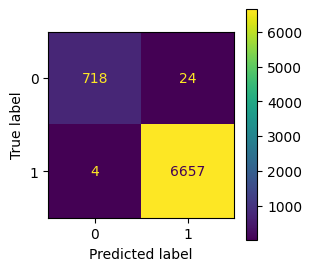

In [169]:
knn = KNeighborsClassifier()
knn.fit(X_train_xgbr, y_train)
pred = knn.predict(X_test_xgbr)

acc = accuracy_score(y_test, pred)
f1score = f1_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)

print('KNN with XGB Selection')
print('-'*25)
print('Accuracy: {:.3f}'.format(acc))
print('Precision: {:.3f}'.format(precision))
print('Recall: {:.3f}'.format(recall))
print('F1-score: {:.3f}'.format(f1score))

fig, ax = plt.subplots(figsize=(3, 3))
ConfusionMatrixDisplay.from_estimator(
    knn,
    X_test_xgbr,
    y_test,
    ax=ax
)

#### K-Nearest Neighbors with Lasso Regularization

KNN Lasso 
-------------------------
Accuracy: 0.998
Precision: 0.998
Recall: 1.000
F1-score: 0.999


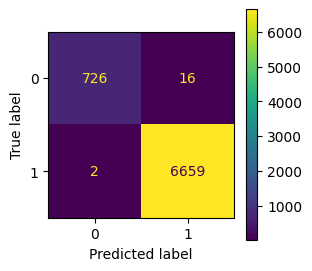

In [170]:
knn = KNeighborsClassifier()
knn.fit(X_train_lasso, y_train)
pred = knn.predict(X_test_lasso)

acc = accuracy_score(y_test, pred)
f1score = f1_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)

print('KNN Lasso ')
print('-'*25)
print('Accuracy: {:.3f}'.format(acc))
print('Precision: {:.3f}'.format(precision))
print('Recall: {:.3f}'.format(recall))
print('F1-score: {:.3f}'.format(f1score))

fig, ax = plt.subplots(figsize=(3, 3))
ConfusionMatrixDisplay.from_estimator(
    knn,
    X_test_lasso,
    y_test,
    ax=ax
)

#### K-Nearest Neighbors with RF Regularization

KNN RF
-------------------------
Accuracy: 0.996
Precision: 0.996
Recall: 1.000
F1-score: 0.998


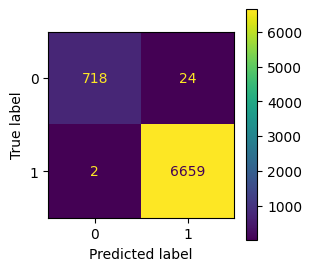

In [171]:
knn = KNeighborsClassifier()
knn.fit(X_train_rf, y_train)
pred = knn.predict(X_test_rf)

acc = accuracy_score(y_test, pred)
f1score = f1_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)

print('KNN RF')
print('-'*25)
print('Accuracy: {:.3f}'.format(acc))
print('Precision: {:.3f}'.format(precision))
print('Recall: {:.3f}'.format(recall))
print('F1-score: {:.3f}'.format(f1score))

fig, ax = plt.subplots(figsize=(3, 3))
ConfusionMatrixDisplay.from_estimator(
    knn,
    X_test_rf,
    y_test,
    ax=ax
)

#### Random Forest With XGB Selection

Random Forest With XGBR selection
-------------------------
Accuracy: 0.999
Precision: 0.999
Recall: 1.000
F1-score: 0.999


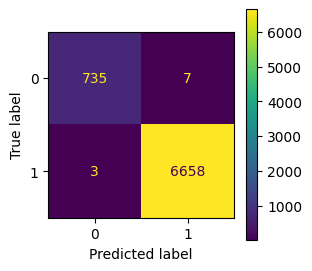

In [172]:
forest = RandomForestClassifier(random_state=RANDOM_STATE)
forest.fit(X_train_xgbr, y_train)
pred = forest.predict(X_test_xgbr)

acc = accuracy_score(y_test, pred)
f1score = f1_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)

print('Random Forest With XGBR selection')
print('-'*25)
print('Accuracy: {:.3f}'.format(acc))
print('Precision: {:.3f}'.format(precision))
print('Recall: {:.3f}'.format(recall))
print('F1-score: {:.3f}'.format(f1score))

fig, ax = plt.subplots(figsize=(3, 3))
ConfusionMatrixDisplay.from_estimator(
    forest,
    X_test_xgbr,
    y_test,
    ax=ax
)

#### Random Forest Classifier With Lasso Regularization

Random Forest Classifier With Lasso Regularization
-------------------------
Accuracy: 0.999
Precision: 1.000
Recall: 1.000
F1-score: 1.000


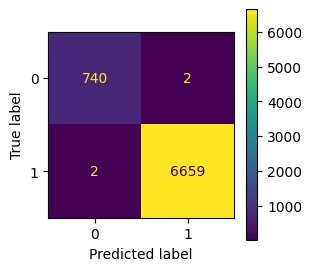

In [173]:
forest = RandomForestClassifier(max_depth=None, random_state=RANDOM_STATE)
forest.fit(X_train_lasso, y_train)
pred = forest.predict(X_test_lasso)

acc = accuracy_score(y_test, pred)
f1score = f1_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)

print('Random Forest Classifier With Lasso Regularization')
print('-'*25)
print('Accuracy: {:.3f}'.format(acc))
print('Precision: {:.3f}'.format(precision))
print('Recall: {:.3f}'.format(recall))
print('F1-score: {:.3f}'.format(f1score))

fig, ax = plt.subplots(figsize=(3, 3))
ConfusionMatrixDisplay.from_estimator(
    forest,
    X_test_lasso,
    y_test,
    ax=ax
)

#### Random Forest Classifier With RF Regularization

Random Forest Classifier With Ridge Regularization
-------------------------
Accuracy: 0.999
Precision: 0.999
Recall: 1.000
F1-score: 1.000


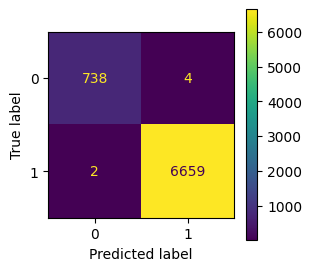

In [174]:
forest = RandomForestClassifier(max_depth=None, random_state=RANDOM_STATE)
forest.fit(X_train_rf, y_train)
pred = forest.predict(X_test_rf)

acc = accuracy_score(y_test, pred)
f1score = f1_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)

print('Random Forest Classifier With Ridge Regularization')
print('-'*25)
print('Accuracy: {:.3f}'.format(acc))
print('Precision: {:.3f}'.format(precision))
print('Recall: {:.3f}'.format(recall))
print('F1-score: {:.3f}'.format(f1score))

fig, ax = plt.subplots(figsize=(3, 3))
ConfusionMatrixDisplay.from_estimator(
    forest,
    X_test_rf,
    y_test,
    ax=ax
)

#### XGBoost with Lasso Regularization

XGBoost with Lasso Regularization
-------------------------
Accuracy: 1.000
Precision: 1.000
Recall: 1.000
F1-score: 1.000


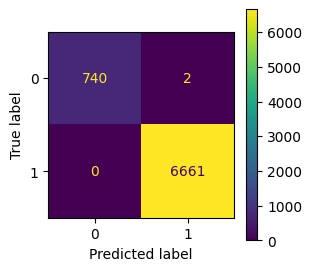

In [175]:
xgb = XGBClassifier(random_state=RANDOM_STATE)
xgb.fit(X_train_lasso, y_train)
pred = xgb.predict(X_test_lasso)

acc = accuracy_score(y_test, pred)
f1score = f1_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)

print('XGBoost with Lasso Regularization')
print('-'*25)
print('Accuracy: {:.3f}'.format(acc))
print('Precision: {:.3f}'.format(precision))
print('Recall: {:.3f}'.format(recall))
print('F1-score: {:.3f}'.format(f1score))

fig, ax = plt.subplots(figsize=(3, 3))
ConfusionMatrixDisplay.from_estimator(
    xgb,
    X_test_lasso,
    y_test,
    ax=ax
)

#### XGBoost with RF Regularization

XGBoost with RF Regularization
-------------------------
Accuracy: 1.000
Precision: 1.000
Recall: 1.000
F1-score: 1.000


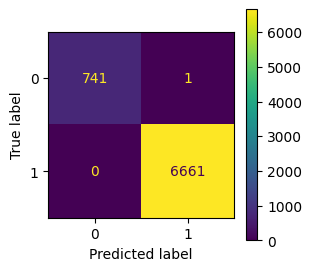

In [176]:
xgb = XGBClassifier(random_state=RANDOM_STATE)
xgb.fit(X_train_rf, y_train)
pred = xgb.predict(X_test_rf)

acc = accuracy_score(y_test, pred)
f1score = f1_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)

print('XGBoost with RF Regularization')
print('-'*25)
print('Accuracy: {:.3f}'.format(acc))
print('Precision: {:.3f}'.format(precision))
print('Recall: {:.3f}'.format(recall))
print('F1-score: {:.3f}'.format(f1score))

fig, ax = plt.subplots(figsize=(3, 3))
ConfusionMatrixDisplay.from_estimator(
    xgb,
    X_test_rf,
    y_test,
    ax=ax
)

#### XGBoost with XGB Selection

XGBoost with xgb Selection
-------------------------
Accuracy: 0.998
Precision: 0.998
Recall: 1.000
F1-score: 0.999


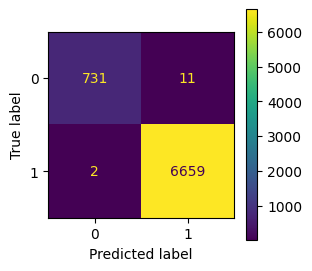

In [177]:
xgb = XGBClassifier(random_state=RANDOM_STATE)
xgb.fit(X_train_xgbr, y_train)
pred = xgb.predict(X_test_xgbr)

acc = accuracy_score(y_test, pred)
f1score = f1_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)

print('XGBoost with xgb Selection')
print('-'*25)
print('Accuracy: {:.3f}'.format(acc))
print('Precision: {:.3f}'.format(precision))
print('Recall: {:.3f}'.format(recall))
print('F1-score: {:.3f}'.format(f1score))

fig, ax = plt.subplots(figsize=(3, 3))
ConfusionMatrixDisplay.from_estimator(
    xgb,
    X_test_xgbr,
    y_test,
    ax=ax
)

----------------
## Model Evaluation
#### XGBoost with RF Feature Selection

XGBoost with RF Feature Selection (Test)
---------------------------------------------
Accuracy: 0.9999
Precision: 0.9998
Recall: 1.0000
F1-score: 0.9999

XGBoost with RF Feature Selection (Validation)
---------------------------------------------
Accuracy: 0.9993
Precision: 0.9994
Recall: 0.9998
F1-score: 0.9996


Text(0.5, 1.0, 'AUC (Validation)')

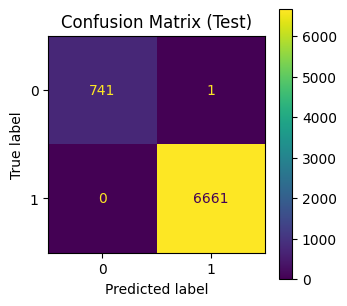

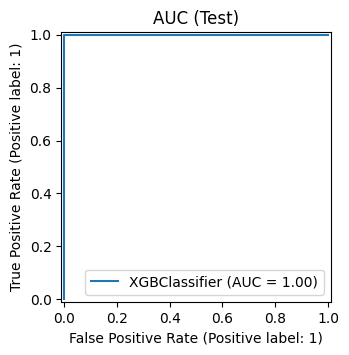

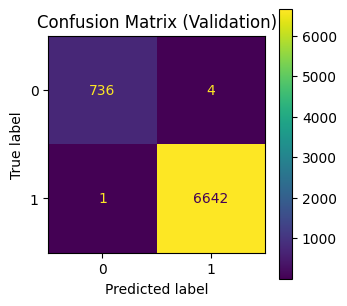

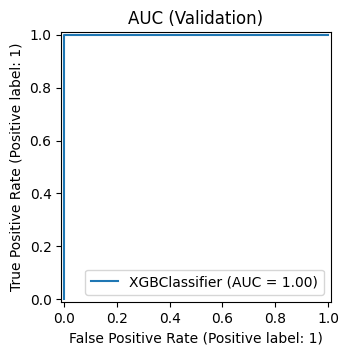

In [178]:
xgb = XGBClassifier(random_state=RANDOM_STATE)
xgb.fit(X_train_rf, y_train)
pred = xgb.predict(X_test_rf)
predVal = xgb.predict(X_val_rf)

acc = accuracy_score(y_test, pred)
f1score = f1_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)

accVal = accuracy_score(y_val, predVal)
f1scoreVal = f1_score(y_val, predVal)
precisionVal = precision_score(y_val, predVal)
recallVal = recall_score(y_val, predVal)


print('XGBoost with RF Feature Selection (Test)')
print('-'*45)
print('Accuracy: {:.4f}'.format(acc))
print('Precision: {:.4f}'.format(precision))
print('Recall: {:.4f}'.format(recall))
print('F1-score: {:.4f}'.format(f1score))

print('\nXGBoost with RF Feature Selection (Validation)')
print('-'*45)
print('Accuracy: {:.4f}'.format(accVal))
print('Precision: {:.4f}'.format(precisionVal))
print('Recall: {:.4f}'.format(recallVal))
print('F1-score: {:.4f}'.format(f1scoreVal))

fig, ax = plt.subplots(figsize=(3.5, 3.5))
ConfusionMatrixDisplay.from_estimator(
    xgb,
    X_test_rf,
    y_test,
    ax=ax)
ax.set_title('Confusion Matrix (Test)')


fig2, ax2 = plt.subplots(figsize=(3.5, 3.5))
RocCurveDisplay.from_estimator(
    xgb,
    X_test_rf,
    y_test,
    ax=ax2)
ax2.set_title('AUC (Test)')

fig3, ax3 = plt.subplots(figsize=(3.5, 3.5))
ConfusionMatrixDisplay.from_estimator(
    xgb,
    X_val_rf,
    y_val,
    ax=ax3)
ax3.set_title('Confusion Matrix (Validation)')

fig4, ax4 = plt.subplots(figsize=(3.5, 3.5))
RocCurveDisplay.from_estimator(
    xgb,
    X_val_rf,
    y_val,
    ax=ax4)
ax4.set_title('AUC (Validation)')

# 0 if 'BENIGN' else 1